Example 1 – Binarization

In [1]:
# --------------------------------------------
# Example 1: Binarization
# Convert numerical values into 0 and 1
# --------------------------------------------

import numpy as np
from sklearn import preprocessing

# Create input data
input_data = np.array([[5.1, -2.9, 3.3],
                       [-1.2, 7.8, -6.1],
                       [3.9, 0.4, 2.2],
                       [2.1, -9.9, -4.5]])

# Apply binarization (threshold = 2.1)
data_binarized = preprocessing.Binarizer(threshold=2.1).transform(input_data)

print("Binarized Data:\n", data_binarized)

Binarized Data:
 [[1. 0. 1.]
 [0. 1. 0.]
 [1. 0. 1.]
 [0. 0. 0.]]


Example 2 – Mean Removal

In [2]:
# --------------------------------------------
# Example 2: Mean Removal (Standardization)
# Center features around zero
# --------------------------------------------

from sklearn import preprocessing

print("BEFORE:")
print("Mean =", input_data.mean(axis=0))
print("Std deviation =", input_data.std(axis=0))

# Remove mean and scale
data_scaled = preprocessing.scale(input_data)

print("\nAFTER:")
print("Mean =", data_scaled.mean(axis=0))
print("Std deviation =", data_scaled.std(axis=0))

BEFORE:
Mean = [ 2.475 -1.15  -1.275]
Std deviation = [2.37526314 6.36651396 4.08312074]

AFTER:
Mean = [9.71445147e-17 0.00000000e+00 0.00000000e+00]
Std deviation = [1. 1. 1.]


Example 3 – Min-Max Scaling

In [3]:
# --------------------------------------------
# Example 3: Min-Max Scaling
# Scale features between 0 and 1
# --------------------------------------------

data_scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
data_scaled_minmax = data_scaler.fit_transform(input_data)

print("Min-Max Scaled Data:\n", data_scaled_minmax)

Min-Max Scaled Data:
 [[1.         0.39548023 1.        ]
 [0.         1.         0.        ]
 [0.80952381 0.5819209  0.88297872]
 [0.52380952 0.         0.17021277]]


Example 4 – Normalization (L1 & L2)

In [4]:
# --------------------------------------------
# Example 4: Normalization
# L1 and L2 normalization
# --------------------------------------------

data_normalized_l1 = preprocessing.normalize(input_data, norm='l1')
data_normalized_l2 = preprocessing.normalize(input_data, norm='l2')

print("L1 Normalized:\n", data_normalized_l1)
print("L2 Normalized:\n", data_normalized_l2)

L1 Normalized:
 [[ 0.45132743 -0.25663717  0.2920354 ]
 [-0.0794702   0.51655629 -0.40397351]
 [ 0.6         0.06153846  0.33846154]
 [ 0.12727273 -0.6        -0.27272727]]
L2 Normalized:
 [[ 0.75765788 -0.43082507  0.49024922]
 [-0.12030718  0.78199664 -0.61156148]
 [ 0.8675239   0.08897681  0.48937246]
 [ 0.18960514 -0.89385281 -0.40629673]]


Example 5 – Linear Regression (Offline Version)

Coefficient: [[0.12258596]]
Intercept: [10.18680993]


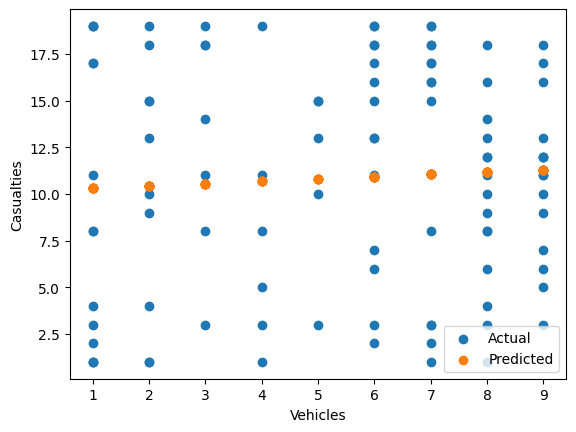

In [5]:
# --------------------------------------------
# Example 5: Simple Linear Regression
# Predict casualties based on vehicles
# --------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Create synthetic dataset
data = pd.DataFrame({
    "Number_of_Vehicles": np.random.randint(1,10,100),
    "Number_of_Casualties": np.random.randint(1,20,100)
})

# Select X and Y
x = data["Number_of_Vehicles"].values.reshape(-1,1)
y = data["Number_of_Casualties"].values.reshape(-1,1)

# Create model
lr = LinearRegression()

# Train model
lr.fit(x,y)

# Get coefficient and intercept
print("Coefficient:", lr.coef_)
print("Intercept:", lr.intercept_)

# Predict
y_pred = lr.predict(x)

# Plot
plt.scatter(x,y,label="Actual")
plt.scatter(x,y_pred,label="Predicted")
plt.xlabel("Vehicles")
plt.ylabel("Casualties")
plt.legend()
plt.show()

1️⃣ Load Diabetes Dataset

In [6]:
# --------------------------------------------
# Step 1: Load Diabetes Dataset
# --------------------------------------------

import pandas as pd
import numpy as np
from sklearn import datasets

# Load dataset
diabetes = datasets.load_diabetes()

# Convert into DataFrame
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target)

print("First 5 rows:")
print(X.head())

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


2️⃣ Split dataset into train/test and shuffle

In [7]:
# --------------------------------------------
# Step 2: Train-Test Split
# --------------------------------------------

from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, shuffle=True
)

print("Training shape:", xtrain.shape)
print("Testing shape:", xtest.shape)

Training shape: (353, 10)
Testing shape: (89, 10)


3️⃣ Use correlation to find most relevant feature

In [8]:
# --------------------------------------------
# Step 3: Correct Correlation Analysis
# --------------------------------------------

pd_data = X.copy()
pd_data["target"] = y

corr = pd_data.corr()

print("Correlation with target:")
print(corr["target"])

# Drop self-correlation
corr_target = corr["target"].drop("target")

# Get most relevant feature
most_relevant_feature = corr_target.abs().idxmax()

print("Most Relevant Feature:", most_relevant_feature)

Correlation with target:
age       0.187889
sex       0.043062
bmi       0.586450
bp        0.441482
s1        0.212022
s2        0.174054
s3       -0.394789
s4        0.430453
s5        0.565883
s6        0.382483
target    1.000000
Name: target, dtype: float64
Most Relevant Feature: bmi


4️⃣ Fit Linear Regression Model and Represent Mathematically

In [9]:
# --------------------------------------------
# Step 4: Train Linear Regression Model
# --------------------------------------------

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# Train model with all features
lr.fit(xtrain, ytrain)

# Get coefficients and intercept
intercept = lr.intercept_
coefficients = lr.coef_

print("Intercept (B0):", intercept)
print("Coefficients (B1...Bn):", coefficients)

Intercept (B0): 151.5840797293476
Coefficients (B1...Bn): [ -42.97093085 -285.258144    512.34891896  333.73821946 -936.93543053
  613.47401128   99.80610481  124.78244351  818.61994371   48.08148281]


5️⃣ Compute Test Accuracy (Single Feature & All Features)

In [10]:
# Accuracy with all features
accuracy_all = lr.score(xtest, ytest)
print("Test Accuracy (All Features):", accuracy_all)

# Train model using only most relevant feature
xtrain_single = xtrain[[most_relevant_feature]]
xtest_single = xtest[[most_relevant_feature]]

lr_single = LinearRegression()
lr_single.fit(xtrain_single, ytrain)

accuracy_single = lr_single.score(xtest_single, ytest)

print("Test Accuracy (Single Feature):", accuracy_single)

Test Accuracy (All Features): 0.5091292869346207
Test Accuracy (Single Feature): 0.36369651962733063


6️⃣ Feature Importance Plot

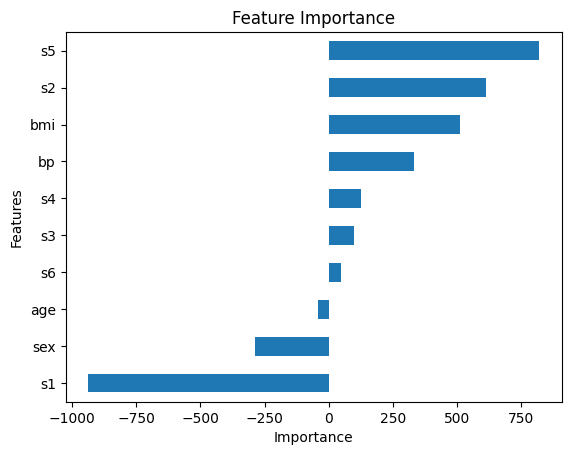

In [11]:
# --------------------------------------------
# Step 6: Feature Importance Plot
# --------------------------------------------

import matplotlib.pyplot as plt

coeff = list(lr.coef_)
labels = list(xtrain.columns)

features = pd.DataFrame()
features['Features'] = labels
features['importance'] = coeff

features.sort_values(by='importance', ascending=True, inplace=True)
features['positive'] = features['importance'] > 0
features.set_index('Features', inplace=True)

features.importance.plot(kind='barh')
plt.xlabel('Importance')
plt.title("Feature Importance")
plt.show()